Saving WhatsApp Image 2026-06-14 at 10.25.52 PM.jpeg to WhatsApp Image 2026-06-14 at 10.25.52 PM.jpeg


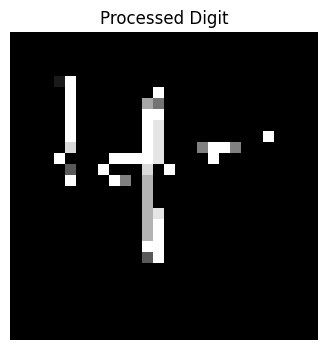

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 543ms/step

Predicted Digit: 4
Confidence: 97.42%


In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from google.colab import files

# =====================================================
# 1. Load trained model
# =====================================================
model = load_model("mnist_cnn_model.h5")

# =====================================================
# 2. Upload image
# =====================================================
uploaded = files.upload()

img_path = list(uploaded.keys())[0]

# =====================================================
# 3. Read image
# =====================================================
img = cv2.imread(img_path)

if img is None:
    raise ValueError("Image could not be loaded!")

# =====================================================
# 4. Convert to grayscale
# =====================================================
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# =====================================================
# 5. Threshold to isolate digit
# =====================================================
_, thresh = cv2.threshold(
    gray,
    180,
    255,
    cv2.THRESH_BINARY_INV
)

# =====================================================
# 6. Find digit contour
# =====================================================
contours, _ = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

if len(contours) == 0:
    raise ValueError("No digit detected!")

# Largest contour = digit
c = max(contours, key=cv2.contourArea)

x, y, w, h = cv2.boundingRect(c)

digit = thresh[y:y+h, x:x+w]

# =====================================================
# 7. Resize digit
# =====================================================
digit = cv2.resize(digit, (20, 20))

# =====================================================
# 8. Place in 28x28 canvas (MNIST style)
# =====================================================
canvas = np.zeros((28, 28), dtype=np.uint8)

canvas[4:24, 4:24] = digit

# =====================================================
# 9. Display processed image
# =====================================================
plt.figure(figsize=(4,4))
plt.imshow(canvas, cmap='gray')
plt.title("Processed Digit")
plt.axis("off")
plt.show()

# =====================================================
# 10. Normalize
# =====================================================
canvas = canvas.astype("float32") / 255.0
canvas = canvas.reshape(1, 28, 28, 1)

# =====================================================
# 11. Predict
# =====================================================
prediction = model.predict(canvas)

predicted_digit = np.argmax(prediction)
confidence = np.max(prediction) * 100

print("\nPredicted Digit:", predicted_digit)
print(f"Confidence: {confidence:.2f}%")